In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [73]:
df = pd.read_csv("../Data/cleaned_data.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [74]:
print(f'Total Customer:{df.shape[0]}')

Total Customer:7032


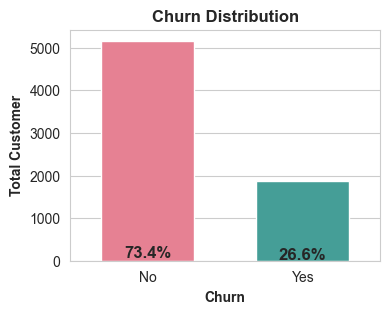

In [75]:
churn_percent = df['Churn'].value_counts(normalize=True)*100

plt.figure(figsize=(4,3))
sns.set_style("whitegrid")
sns.countplot(
    df, x='Churn',
    palette="husl",
    width=0.6,
    legend="full"
)
plt.title("Churn Distribution", weight='bold')
plt.xlabel('Churn', weight='bold')
plt.ylabel('Total Customer', weight='bold')
for i, v in enumerate(churn_percent.values):
    plt.text(i, v+1, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=12)
plt.show()


In [76]:
def churn_count_plot(df, category_col, churn_col='Churn', palette='viridis', ax=None):
    sns.set_style("whitegrid")
    sns.countplot(
        data=df, 
        x=category_col,
        hue=churn_col,
        palette=palette, 
        ax=ax
    )
    ax.set_title(f"{category_col} Count by Churn", weight='bold')
    ax.set_xlabel(category_col, weight='bold')
    ax.set_ylabel("Total Customer", weight='bold')
    for container in ax.containers:
        ax.bar_label(container)

def churn_rate_plot(df, category_col, churn_col='Churn', palette='viridis', ax=None):
    sns.set_style("whitegrid")
    churn_rate = pd.crosstab(df[category_col], df[churn_col], normalize=True) * 100
    churn_rate_yes = churn_rate['Yes'].sort_values(ascending=False)

    sns.barplot(
        x=churn_rate_yes.index, 
        y=churn_rate_yes.values, 
        palette=palette, 
        ax=ax
    )
    ax.set_title(f"{category_col} Churn Rate (%)", weight='bold')
    ax.set_xlabel(category_col, weight='bold')
    ax.set_ylabel("Churn Rate (%)", weight='bold')

    for i, value in enumerate(churn_rate_yes.values):
        ax.text(i, value + 0.3, f"{value:.2f}%", ha='center', va='bottom', weight='bold')


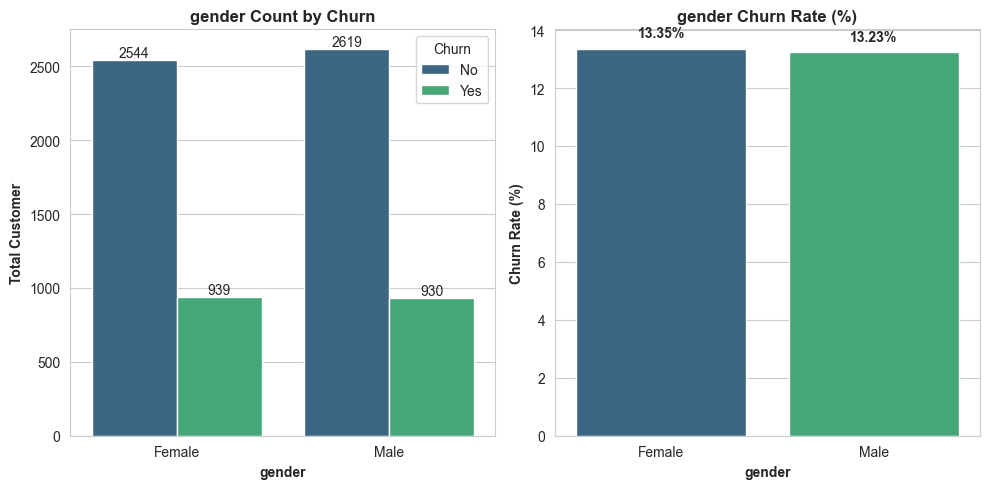

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
churn_count_plot(df, category_col='gender', ax=axes[0])
churn_rate_plot(df, category_col='gender',  ax=axes[1])
plt.tight_layout()
plt.show()

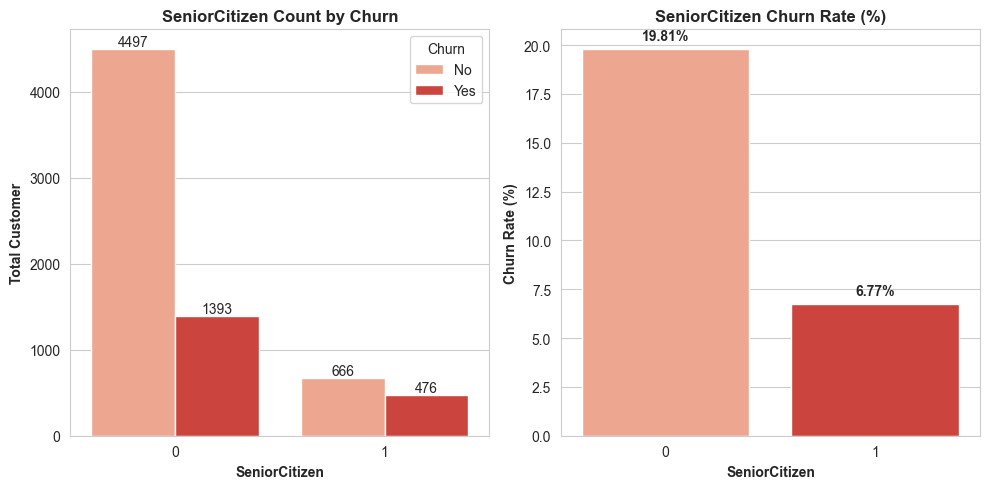

In [78]:
df['SeniorCitizen_label'] = df['SeniorCitizen'].map({0: 'No', 1:'Yes'})
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
churn_count_plot(df, category_col='SeniorCitizen', ax=axes[0], palette='Reds')
churn_rate_plot(df, category_col='SeniorCitizen',  ax=axes[1], palette='Reds')
plt.tight_layout()
plt.show()

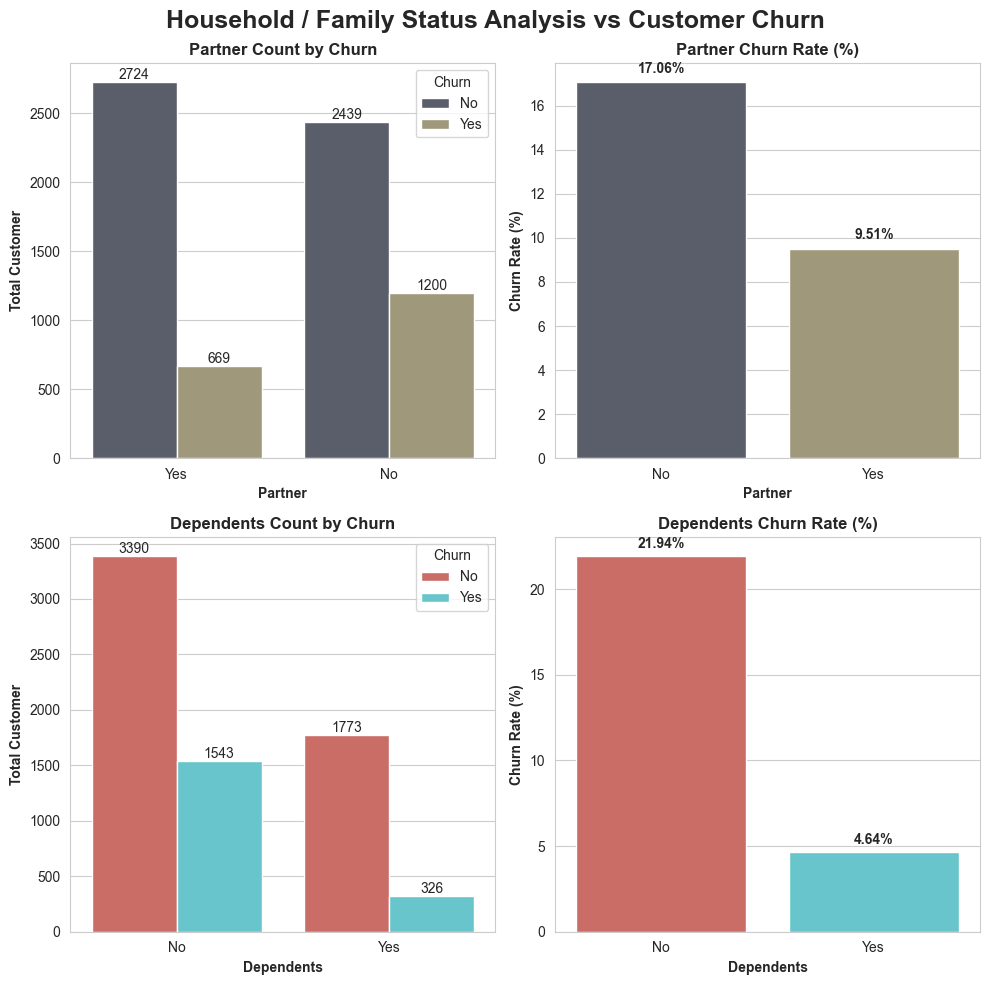

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
churn_count_plot(df, category_col='Partner', ax=axes[0, 0], palette='cividis')
churn_rate_plot(df, category_col='Partner',  ax=axes[0, 1], palette='cividis')

churn_count_plot(df, category_col='Dependents', ax=axes[1, 0], palette='hls')
churn_rate_plot(df, category_col='Dependents',  ax=axes[1, 1], palette='hls')

fig.suptitle("Household / Family Status Analysis vs Customer Churn", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

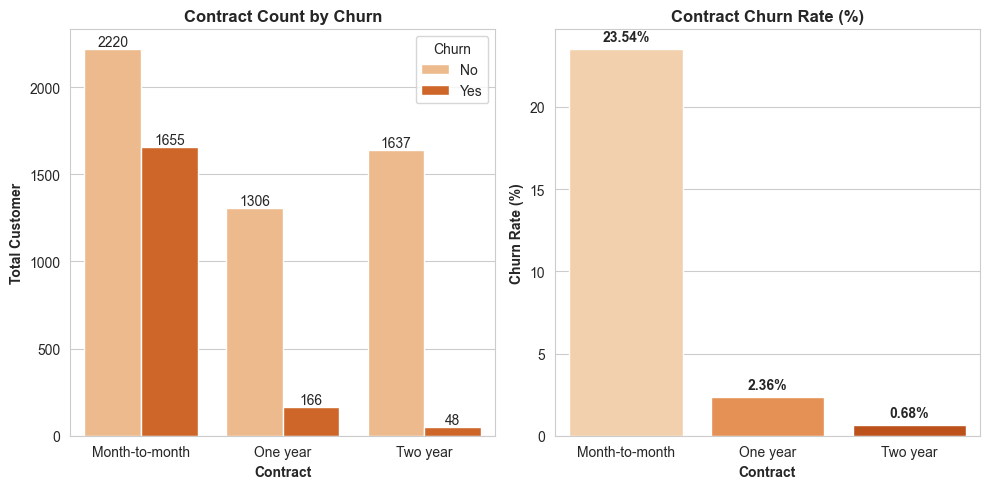

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
churn_count_plot(df, category_col='Contract', ax=axes[0], palette='Oranges')
churn_rate_plot(df, category_col='Contract',  ax=axes[1], palette='Oranges')
plt.tight_layout()
plt.show()

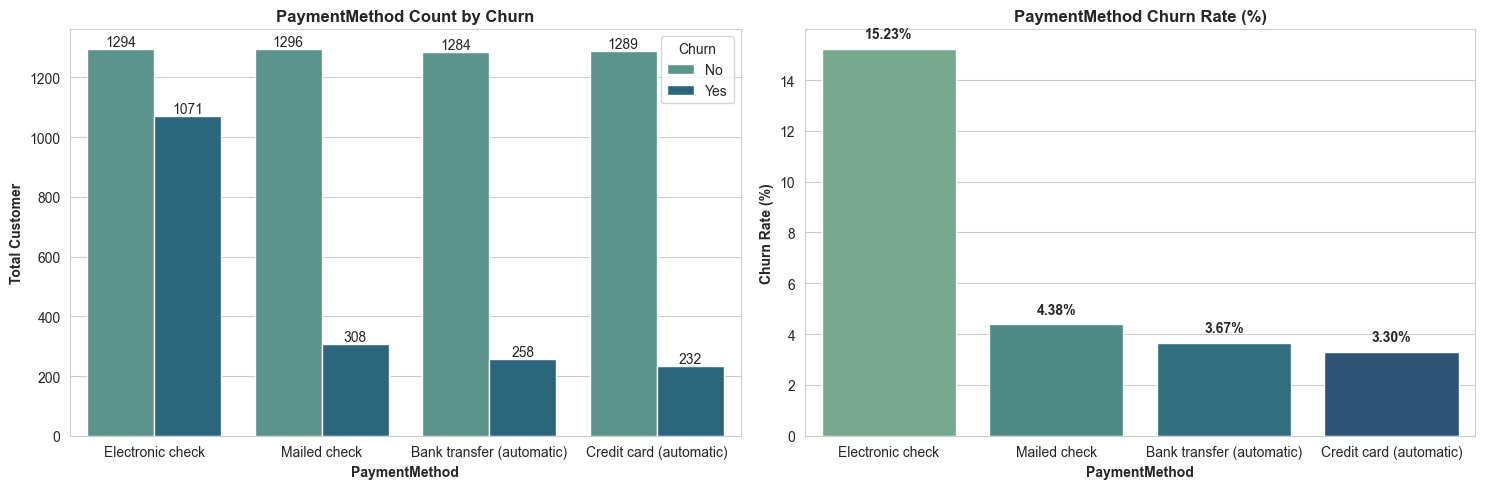

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
churn_count_plot(df, category_col='PaymentMethod', ax=axes[0], palette='crest')
churn_rate_plot(df, category_col='PaymentMethod',  ax=axes[1], palette='crest')
plt.tight_layout()
plt.show()

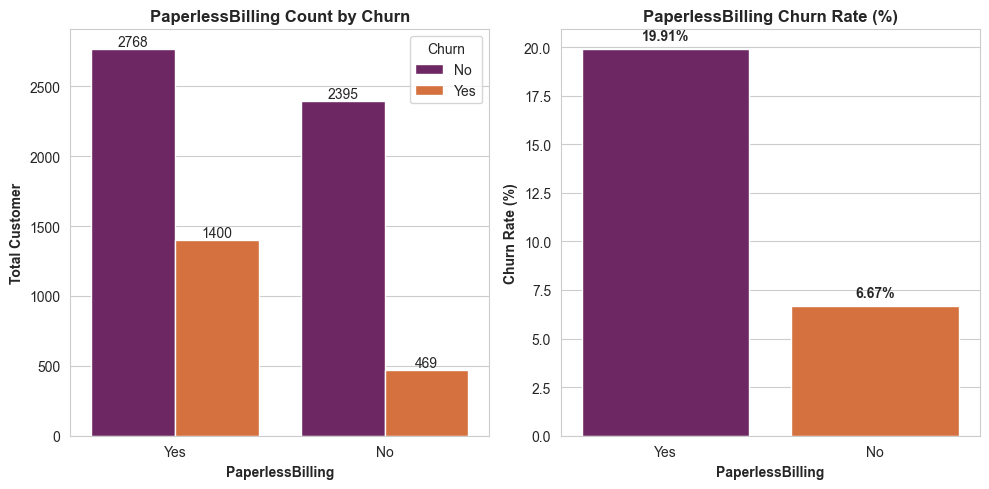

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
churn_count_plot(df, category_col='PaperlessBilling', ax=axes[0], palette='inferno')
churn_rate_plot(df, category_col='PaperlessBilling',  ax=axes[1], palette='inferno')
plt.tight_layout()
plt.show()

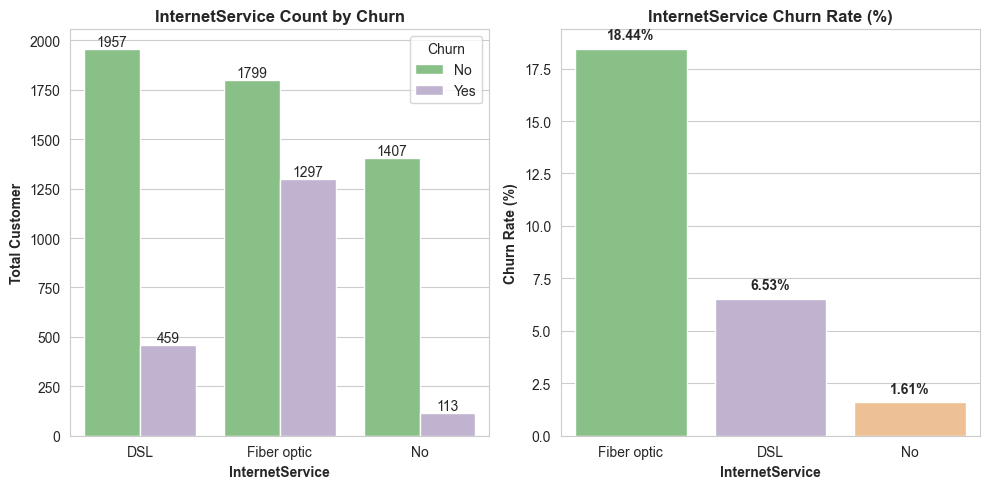

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
churn_count_plot(df, category_col='InternetService', ax=axes[0], palette='Accent')
churn_rate_plot(df, category_col='InternetService',  ax=axes[1], palette='Accent')
plt.tight_layout()
plt.show()